# S.1 Supplementary material: frazil ice concentration error propagation and simulation

In [1]:
# FIC analysis simulation — Python version (NumPy, pandas, xarray, matplotlib)
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------
# Reproducibility
# ---------------------------------------
rng = np.random.default_rng(seed=100)  # Equivalent to R's set.seed(100)

# ---------------------------------------
# Camera set-up
# ---------------------------------------
l1 = 0.05 # increase assumed depth of field to account for more uncertainty
l2 = 2.95
# l1 = 0.4
# l2 = 1.12
l = (l1 + l2) / 2

N = 10000

## 1. Frazil ice crystal size uncertainty estimate

The image is projected onto a plane the object distance $l$ metres from the camera; the volume of seawater was captured between $l_1 = l-0.5 DoF$ metres and $l_2=l+0.5 DoF$ metres from the camera (Fig. 5), where $l$ is the focal distance and $DoF$ stands for depth of field.

Let $D_{app}$ (m) be the apparent diameter of a frazil ice crystal with $D$ (m) the true diameter:

$D_{app} = D \frac{l}{x},$

where $x$ the distance between the crystal and the camera. We then propagate the errors for $D = \frac{x}{l} D_{app}$

$\frac{\Delta D}{D} = \frac{\Delta x}{x} + \frac{\Delta D_{app}}{D_{app}},$

where $\frac{\Delta D}{D}$ the relative error in the position of the crystal relative to the camera (m), and $\frac{\Delta D_{app}}{D_{app}}$ the relative error in the measured apparent diameter (m).

Because our analysis is focused on mean crystal diameters, uncertainties associated with individual crystal measurements are not considered independently, as they can distract from the quantity of interest. Single‑crystal diameter estimates are therefore not meaningful on their own (e.g. Taylor, 1996).

For the mean diameter, averaged over all crystals ($n \approx$ 10000) within a stack of images from a single deployment, the relative uncertainty decreases as

$\frac{\Delta mean(D)}{mean(D)} = \frac{1}{\sqrt{n}} \frac{\Delta D}{D}$

Combination with the error propagation gives

$\frac{\Delta mean(D)}{mean(D)} = \frac{1}{\sqrt{n}}\frac{1}{2} \frac{l_2 - l_1}{l} + \frac{1}{\sqrt{n}}\frac{\sigma_1}{D_{app}} + \frac{1}{\sqrt{n}}\frac{\epsilon_{w, frame}}{\bar{w}_{frame}},$

where $\sigma_1$ is 0.5 pixels for segmentation inaccuracies (Fig. 10) multiplied with the scaling factor 1.3 (mm/pixel), $\epsilon_{w, frame}$ the error in frame width in metres (Figure 5) and $\bar{w}_{frame}$ the estimated frame width in metres (derived from Table 1).


In [2]:
from IPython.display import display, Markdown
sigma1 = 1.3*1e-3*0.5
D_app = 3e-3 # m
n = N
epsilon_w_frame = 0.2 # m
w_frame_bar = 2.5 # m

rel_error_size_x = 0.5*(l2-l1)/l / np.sqrt(n)
rel_error_size_Dapp = sigma1 / D_app / np.sqrt(n)
rel_error_size_scale = epsilon_w_frame / w_frame_bar / np.sqrt(n)
rel_error_size = np.sqrt(rel_error_size_x**2+rel_error_size_Dapp**2+ rel_error_size_scale**2)

display(Markdown(f"""
We assume that $D_{{app}}$ = 3 mm, because the optical images showed large crystals and a previous study reported large suspended crystals at a site nearby (Stevens et al. 2023).

For a single crystal the relative error contributions then become:

- Geometric factor: $\\approx {100*rel_error_size_x:.2f}$ %
- Crystal edge uncertainty: $\\approx {100*rel_error_size_Dapp:.2f}$ %
- Scaling uncertainty due to auto-focus: ${100*rel_error_size_scale:.2f}$ %

The geometric factor is the dominant error. Error propagation then gives the total relative error:

$\\frac{{\Delta D}}{{D}} \\approx {100*rel_error_size:.2f}$ %
"""))

<>:25: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:25: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/tmp/ipykernel_62835/3455606751.py:25: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  """))



We assume that $D_{app}$ = 3 mm, because the optical images showed large crystals and a previous study reported large suspended crystals at a site nearby (Stevens et al. 2023).

For a single crystal the relative error contributions then become:

- Geometric factor: $\approx 0.97$ %
- Crystal edge uncertainty: $\approx 0.22$ %
- Scaling uncertainty due to auto-focus: $0.08$ %

The geometric factor is the dominant error. Error propagation then gives the total relative error:

$\frac{\Delta D}{D} \approx 0.99$ %


## 2. Frazil Ice Crystal Volume Uncertainty Estimate

### Volume of a Single Frazil Ice Crystal

The volume of the crystal is taken to be

$V = \frac{D^3}{\tau}$

where $\tau$ is the diameter-to-thickness aspect ratio of the crystals, approximately $\tau = 37 \pm 11$ (McFarlane et al. 2014).

We now propagate the uncertainty in $x$, $D_{app}$, and $\tau$.



### Physics / Pragmatic Approach

We can express the volume as:

(1) $V = \frac{x^3 D_{\text{app}}^3}{l^3 \tau}$

Apply logarithmic differentiation to the calculus method for error propagation:

(2) $\ln (V) = 3 ln (x) + 3 \ln (D_{app}) - 3 ln (l) - ln (\tau)$ 

For differentiation assuming independent variables we first apply the chain rule

(3) $\frac{\partial \ln (V)}{V} = \frac{\partial V}{V} = 3 \frac{\partial x}{x} + 3 \frac{\partial D_{app}}{D_{app}} - \frac{\partial \tau}{\tau}$

Then we convert to absolute values to obtain the error propagation

(4) $\frac{\Delta V}{V} \approx 3 \frac{\Delta x}{x} + 3 \frac{\Delta D_{\text{app}}}{D_{\text{app}}} + \frac{\Delta \tau}{\tau}$

where $\Delta x = \frac{1}{2}(l_2 - l_1)$. Then:

(5) $\frac{\Delta V}{V} \approx \frac{3}{2} \frac{l_2 - l_1}{l} + 3 \frac{\sigma_1}{D_{\text{app}}} + \frac{\sigma_2}{\tau}$

Where $\sigma_2$ is the uncertainty in the diameter-to-tickness ratio $\tau$, namely 11.

### Total Volume of Frazil Ice

$V_{\text{tot}} = \sum_{i=1}^{n} V_i$

and its uncertainty:

$\Delta V_{\text{tot}} = \sqrt{\sum_{i=1}^n (\Delta V_i)^2}$

If $n$ the average number of crystals per set of frames, the maximum relative error becomes:

$\frac{\Delta V_{\text{tot}}}{V_{\text{tot}}} = \frac{1}{\sqrt{n}} \frac{\Delta V}{V}$

$\frac{\Delta FIC}{FIC} = \rho_i \frac{\Delta V_{\text{tot}}}{V_{\text{tot}}}$

In [3]:
sigma2 = 11
tau = 37
from scipy.integrate import quad
# Compute each contribution
# Define the interval
x1, x2 = l1, l2

# Define the unnormalized probability density function
def p(x):
    return x**2

# Compute the normalization constant
normalization_constant, _ = quad(p, x1, x2)

# Define the normalized probability density function
def p_normalized(x):
    return p(x) / normalization_constant

# Compute the mean of x
def mean_x():
    integrand = lambda x: x * p_normalized(x)
    mean, _ = quad(integrand, x1, x2)
    return mean

# Compute the standard deviation of x
def std_x(mean):
    integrand = lambda x: ((x - mean)**2) * p_normalized(x)
    variance, _ = quad(integrand, x1, x2)
    return np.sqrt(variance)

# Calculate mean and standard deviation
mean = mean_x()
std = std_x(mean)

rel_error_geom = 3 * std/mean / np.sqrt(n)
rel_error_thresh = 3 * (sigma1 / D_app) / np.sqrt(n)
rel_error_tau = sigma2 / tau / np.sqrt(n)
rel_error = np.sqrt(rel_error_geom**2 + rel_error_thresh**2 + rel_error_tau**2)
rel_error_total = rel_error
rel_error_total_mgL = rel_error_total

display(Markdown(f"""
Relative error contributions:

- Geometric factor: $\\approx {100*rel_error_geom:.2f}$ %
- Crystal edge uncertainty: $\\approx {100*rel_error_thresh:.2f}$ %
- Aspect ratio factor: $\\approx {100*rel_error_tau:.2f}$ %

Combined (used here): 

$\\frac{{\\Delta V_{{tot}}}}{{V_{{tot}}}} \\approx {100*rel_error:.2f}$ %

Indicating that uncertainty in $x$ is likely the dominant error term.
"""))



Relative error contributions:

- Geometric factor: $\approx 0.77$ %
- Crystal edge uncertainty: $\approx 0.65$ %
- Aspect ratio factor: $\approx 0.30$ %

Combined (used here): 

$\frac{\Delta V_{tot}}{V_{tot}} \approx 1.05$ %

Indicating that uncertainty in $x$ is likely the dominant error term.


# 3. Simulations

## a) Geometry moments (x $\propto$ x$^2$ on [l$_1$, l$_2$])

With density $f(x)=\frac{3x^2}{l_2^3-l_1^3}$ on $[l_1,l_2]$, the analytical moments used to debias foreshortening are:
$$
\mu_1 = \mathbb{E}[x] = \frac{3\,(l_2^4 - l_1^4)}{4\,(l_2^3 - l_1^3)},\quad
\mu_2 = \mathbb{E}[x^2] = \frac{3\,(l_2^5 - l_1^5)}{5\,(l_2^3 - l_1^3)}
$$
$$
\mu_{-1} = \mathbb{E}\!\left[\frac{1}{x}\right] = \frac{3\,(l_2^2 - l_1^2)}{2\,(l_2^3 - l_1^3)},\quad
\mu_{-3} = \mathbb{E}\!\left[\frac{1}{x^3}\right] = \frac{3\,(\ln l_2 - \ln l_1)}{(l_2^3 - l_1^3)}
$$

## b) Frazil‑ice setup & estimators

Parameters (constants in the simulation): mean diameter ($\mu_d$=1 mm; Frazer et al. 2020), ($\sigma_d$=0.5), ice density ($\rho_i$=917 kg m$^{-3}$), frames ($N_{\text{frames}}$=1400), base ($w$=2.5 m, $h$=1.4 m), masks ($w_{\text{mask}}$=0.728, $h_{\text{mask}}$=0.793), depth‑of‑field ($l$=DoF=0.11 m).  
Field‑of‑view volume per frame (frustum difference):
$$
V_{\text{frame}}=\frac{w\,h\,l}{3}-\frac{w_{\text{mask}}\,h_{\text{mask}}\,l}{3}
$$

**Simulation (per trial):** sample locations $x$ via inverse‑CDF of $x^3$ on $[l_1,l_2]$; draw actual diameters $d_i\sim \mathcal{N}(\mu_d,\sigma_d)$ (lognormal alternative optional); volumes $V_i=d_i^3$. Apparent diameters/volumes from geometry:
$$
d = d_i\,\frac{l}{x},\qquad V = d^3
$$

**Unbiased estimators (geometry‑corrected):**
$$
\hat{D}=\frac{\overline{d}}{\mu_{-1}\,l},\qquad
\hat{V}=\frac{\overline{V}}{\mu_{-3}\,l^3}
$$


### **Errors due to crystal location**

To quantify the bias introduced purely by the crystals’ positions within the depth‑of‑field, we compare the true (sampled) means with their geometry‑corrected estimates:

**Diameter error**
$$
\bigl|\,\mathrm{mean}(d_i)\;-\;\hat{D}\,\bigr|
$$

**Volume error**
$$
\bigl|\,\mathrm{mean}(V_i)\;-\;\hat{V}\,\bigr|
$$

These error estimates capture the bias due to the analytic moments using reasonable assumptions for $l_1$ and $l_2$ (Taylor 1982, 4.6).

mean(dM) = 0.999293
sd(dM)   = 0.008546
mean(VM) = 1.668800
sd(VM)   = 0.697307

Pandas results head:
    trial        dM        VM
0      1  1.004949  1.790317
1      2  0.996969  1.231211
2      3  0.984584  1.203667
3      4  0.992047  1.226985
4      5  1.002814  1.565156 



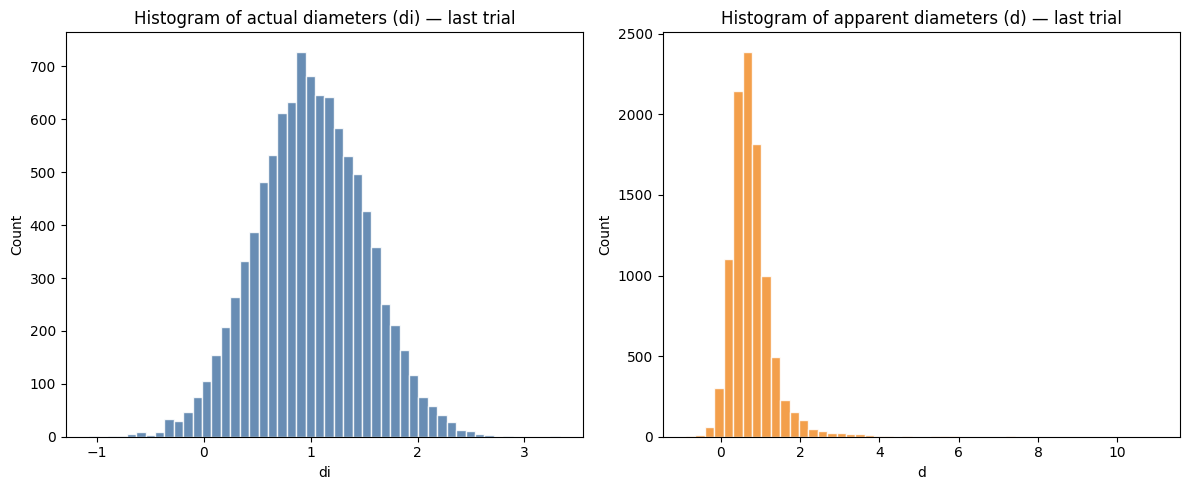

In [4]:
# ---------------------------------------
# Frazil ice details — number and diameter
# ---------------------------------------
mu_d = 1. # from data, uncertain due to auto-focus!
sig_d = 0.5
m = -7.8 + np.log(1000)
s = 1.3
Rhoi = 917 # kg/m3
N_frames = 1400
w = 2.5 # base width m
h = 1.4 # base length m
w_mask = 0.728 # masked pixels due to brick removal
h_mask = 0.793 # masked pixels due to brick removal
DoF = 0.11 # m
V_frame = (w * h * l)/3 - (w_mask * h_mask * l)/3

mu_1 = 3 * (l2**4 - l1**4) / (4 * (l2**3 - l1**3))
mu_2 = 3 * (l2**5 - l1**5) / (5 * (l2**3 - l1**3))
mu_neg1 = 3 * (l2**2 - l1**2) / (2 * (l2**3 - l1**3))
mu_neg3 = 3 * (np.log(l2) - np.log(l1)) / (l2**3 - l1**3)

M = 100  # number of trials

# Storage for per-trial estimators
dM = np.empty(M)  # mean diameter estimator
VM = np.empty(M)  # mean volume estimator
dD = np.empty(M)  # mean diameter error estimator
dV = np.empty(M)  # mean volume error estimator

# To mimic R's hist(di); hist(d), we keep the last trial's di and d
last_di = None
last_d = None

# ---------------------------------------
# Simulation loop (clear and faithful to your R code)
# ---------------------------------------
for m in range(M):
    # locations (x) distributed with density proportional to x^2 over [l1, l2]
    # implemented via inverse CDF for x^3
    x = (l1**3 + (l2**3 - l1**3) * rng.random(N)) ** (1/3)

    # actual diameter and volume
    di = rng.normal(loc=mu_d, scale=sig_d, size=N)
    # di = rng.lognormal(mean = m, sigma = s, size = N)
    # di = di[di>0]
    Vi = di**3

    # apparent diameter and volume (geometry transform)
    d = di * l / x
    V = d**3

    # estimators (same normalization as in R)
    dM[m] = np.mean(d) / (mu_neg1 * l)
    VM[m] = np.mean(V) / (mu_neg3 * l**3)

    dD[m] = np.abs(np.mean(d)-dM[m])
    dV[m] = np.abs(np.mean(V)-VM[m])

    # store last trial data for histograms (matching R behavior)
    last_di = di
    last_d = d

# ---------------------------------------
# Summary stats
# ---------------------------------------
dM_mean = np.mean(dM)
dM_sd = np.std(dM, ddof=1)  # sample std dev, matches R's sd()

VM_mean = np.mean(VM)
VM_sd = np.std(VM, ddof=1)
VM_sd_m3 = VM_sd*1e-9
VM_mean_m3 = VM_mean*1e-9
FIC_mg_L_sd = N * VM_sd_m3 * 1e3 * Rhoi / (N_frames * w * h * DoF)
FIC_mg_L_mean = N * VM_mean_m3 * 1e3 * Rhoi / (N_frames * w * h * DoF)

print(f"mean(dM) = {dM_mean:.6f}")
print(f"sd(dM)   = {dM_sd:.6f}")
print(f"mean(VM) = {VM_mean:.6f}")
print(f"sd(VM)   = {VM_sd:.6f}")

# ---------------------------------------
# Store results with pandas and xarray
# ---------------------------------------
df_results = pd.DataFrame({
    "trial": np.arange(1, M+1),
    "dM": dM,
    "VM": VM
})

# xarray Dataset (nice for labeled multi-dim data)
ds = xr.Dataset(
    {
        "dM": (("trial",), dM),
        "VM": (("trial",), VM),
    },
    coords={"trial": np.arange(1, M+1)}
)

# Optional: show quick summary
print("\nPandas results head:\n", df_results.head(), "\n")

# ---------------------------------------
# Histograms (using last trial di and d)
# ---------------------------------------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(last_di, bins=50, color="#4e79a7", alpha=0.85, edgecolor="white")
plt.title("Histogram of actual diameters (di) — last trial")
plt.xlabel("di")
plt.ylabel("Count")
# plt.xscale("log")

plt.subplot(1, 2, 2)
plt.hist(last_d, bins=50, color="#f28e2b", alpha=0.85, edgecolor="white")
plt.title("Histogram of apparent diameters (d) — last trial")
plt.xlabel("d")
plt.ylabel("Count")
# plt.xscale("log")

plt.tight_layout()
plt.show()

rel_uncertainty_D_mean_prop_sim = np.sqrt((np.mean(dD)/dM_mean)**2 + rel_error_size**2)
rel_uncertainty_V_mean_prop_sim = np.sqrt((np.mean(dV)/VM_mean)**2 + rel_error_total**2)

rel_error_D_mean_prop_sim = np.sqrt((dM_sd/dM_mean)**2 + rel_error_size**2)
rel_error_V_mean_prop_sim = np.sqrt((VM_sd/VM_mean)**2 + rel_error_total**2)

# 3. Final errors for mean diameter and frazil ice concentration

## a) mean diameter
We add the errors due to unknown positioning (from the simulations), the crystal edge uncertainty and the scaling uncertainty in quadrature.

$\frac{\Delta D}{D}
=
\sqrt{
  \left( \frac{\delta_{sys}D}{\hat{D}} \right)^2
  +
  \left( \frac{1}{\sqrt{n}} \frac{\sigma_1}{D_{\mathrm{app}}} \right)^2
  +
  \left( \frac{1}{\sqrt{n}} \frac{\epsilon_{w,\mathrm{frame}}}{\bar{w}_{\mathrm{frame}}} \right)^2
}$

where $\hat{D}$ the estimated true diameter based on the analytic moments.

## b) frazil ice concentration
We add the errors due to unknown positioning (from the simulations), the crystal edge uncertainty and the diameter-to-thickness ratio uncertainty in quadrature.
$\frac{\Delta FIC}{FIC} = 
\sqrt{
\left( \frac{\delta_{sys}V}{\hat{V}} \right)^2
+ \left( \frac{3}{\sqrt{n}} \cdot \frac{\sigma_1}{D_{\text{app}}} \right)^2
+ \left( \frac{1}{\sqrt{n}} \cdot \frac{\sigma_2}{\tau} \right)^2}$
 
where $\hat{V}$ the estimated true ice volumes based on the analytic moments.

We applied this relative error to the results reported in Figure 9. For example, the FIC was 29 mg L$^{-1}$ at 10 m depth, and 0.082 mg L$^{-1}$ at 20 m depth. Multiplication with the relative error in mean crystal volume yielded:

In [5]:
icefin_10m =  f"{3.4e-5 * rel_error_V_mean_prop_sim:.2e}"
icefin_20m =  f"{8.9e-8 * rel_error_V_mean_prop_sim:.2e}"

display(Markdown(f"""

* $FIC = 3.4 \\times 10^{{-5}} \\pm {icefin_10m}$ m³/m³ for 10 m depth  
* $FIC = 8.9 \\times 10^{{-8}} \\pm {icefin_20m}$ m³/m³ for 20 m depth

"""))



* $FIC = 3.4 \times 10^{-5} \pm 1.42e-05$ m³/m³ for 10 m depth  
* $FIC = 8.9 \times 10^{-8} \pm 3.72e-08$ m³/m³ for 20 m depth

